In [2]:
import torch
from pathlib import Path
from torchvision.utils import make_grid
from types import SimpleNamespace
from senn.utils.stability_white_noise import *
import matplotlib.pyplot as plt
from captum.attr import Lime
from captum._utils.models.linear_model import SkLearnLinearRegression

%matplotlib inline

In [3]:
from senn.models import *
from senn.models.senn import SENN
from senn.models.parameterizers import ConvParameterizer
from senn.models.conceptizers import IdentityConceptizer
from senn.models.aggregators import SumAggregator

In [4]:
plt.style.use('seaborn-v0_8-talk')

## Load data and create perturbed images

In [5]:
config = {
    "train": False,
    "conceptizer": "IdentityConceptizer",
    "image_size": 28,
    "concept_dim": 1,
    "parameterizer": "ConvParameterizer",
    "cl_sizes": [1, 10, 20],
    "hidden_sizes": [320, 7840],
    "num_concepts": 784,
    "num_classes": 10,
    "dropout": 0.5,
    "aggregator": "SumAggregator",
    "device": "cpu",
    "lr": 2e-4,
    "epochs": 10,
    "robustness_loss": "mnist_robustness_loss",
    "robust_reg": 1e-2,
    "concept_reg": 1,
    "print_freq": 100,
    "exp_name": "IdentityConc_lambda1e-2_c5_seed29",
    "dataloader": "fashion_mnist",
    "data_path": "datasets/data/fashion_mnist_data",
    "batch_size" : 200,
    "sparsity_reg" : 2e-5,
    "eval_freq" : 270,
    "manual_seed": 29
  }
config = SimpleNamespace(**config)

In [6]:
from senn.datasets.dataloaders import get_dataloader
train_dl, val_dl, test_dl = get_dataloader(config)

x_b, y_b = next(iter(test_dl))

In [25]:
mask_sneaker = (y_b == 7)
x_target = x_b[mask_sneaker][4]
print(x_target.shape)

torch.Size([1, 28, 28])


In [14]:
n_neighbors = 1
neighbors = x_target.unsqueeze(0).repeat(n_neighbors, 1, 1, 1)

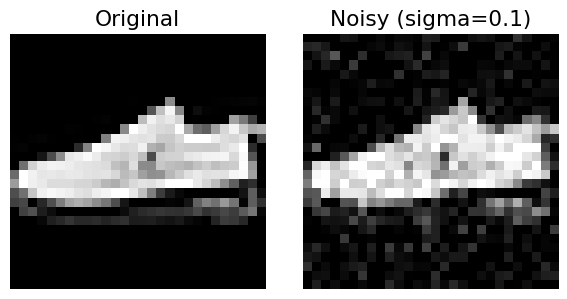

In [15]:
# Add white noise
torch.manual_seed(0)
sigma = 0.1
neighbors_norm, neighbors_pix = add_white_noise(neighbors, sigma=sigma)

# Original -> pixel space too (same domain as neighbors_pix)
x_target_pix = denormalize(x_target.unsqueeze(0)).clamp(0, 1)   # [1,1,28,28]
single_neighbor = neighbors_pix[0:1]  # [1,1,28,28]

images_to_plot = torch.cat([x_target_pix, single_neighbor], dim=0)

# Simpler and robust plotting
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(images_to_plot[0, 0].cpu(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(images_to_plot[1, 0].cpu(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title(f"Noisy (sigma={sigma})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [16]:
conceptizer= eval(config.conceptizer)(**config.__dict__)
parameterizer = eval(config.parameterizer)(**config.__dict__)
aggregator = eval(config.aggregator)(**config.__dict__)
model = SENN(conceptizer, parameterizer, aggregator)

In [10]:
checkpoint_path = Path('results')
model_file = checkpoint_path / config.exp_name / "checkpoints" / "best_model.pt" 
checkpoint = torch.load(model_file, map_location=config.device, weights_only=False)
print(f"Loading trained model: {model_file}")
model.load_state_dict(checkpoint['model_state'])
model.to(config.device)
model.eval()

Loading trained model: results/IdentityConc_lambda1e-2_c5_seed29/checkpoints/best_model.pt


SENN(
  (conceptizer): IdentityConceptizer(
    (encoder): ModuleList()
    (decoder): ModuleList()
  )
  (parameterizer): ConvParameterizer(
    (cl_layers): Sequential(
      (0): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
      (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (2): ReLU()
      (3): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
      (4): Dropout2d(p=0.5, inplace=False)
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): ReLU()
    )
    (fc_layers): Sequential(
      (0): Linear(in_features=320, out_features=7840, bias=True)
      (1): Dropout(p=0.5, inplace=False)
      (2): Tanh()
    )
  )
  (aggregator): SumAggregator()
)

## Saliency maps

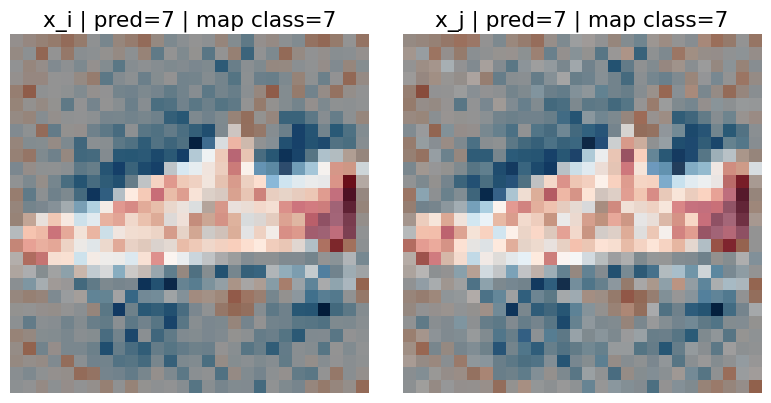

In [11]:
plot_stability_comparison(
    model=model,
    x_i_norm=x_target,
    x_j_norm=neighbors_norm[0:1], 
    mean=MEAN,
    std=STD,
)

## LIME

In [ ]:
# Recover original image explanations
all_clean_labels = torch.load("results/fashion_mnist_lambda1e-2_c5_seed29/posthoc/lime_labels.pt")
all_clean_attrs = torch.load("results/fashion_mnist_lambda1e-2_c5_seed29/posthoc/lime_attributions.pt")
all_clean_preds = torch.load("results/fashion_mnist_lambda1e-2_c5_seed29/posthoc/lime_predictions.pt")

# Retrieve the same image used in SENN
sneaker_indices = (all_clean_labels == 7).nonzero(as_tuple=True)[0]
i = sneaker_indices[4].item()

attr_clean = all_clean_attrs[i] # saliency map
clean_pred = all_clean_preds[i].item()

Saved results contain 200 images
Class distribution: {0: 20, 1: 27, 2: 27, 3: 17, 4: 21, 5: 16, 6: 16, 7: 20, 8: 18, 9: 18}


In [27]:
import torch.nn as nn

# Copia qui la classe esatta che hai in run_lime.py
class SENNWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, x):
        # Captum/LIME ha bisogno dei logit o delle probabilità
        return self.model(x)[0] # o qualunque cosa faccia il tuo wrapper originale

# E poi la usi normalmente
wrapper = SENNWrapper(model).to("cpu")

In [28]:
from captum.attr import Lime
from captum._utils.models.linear_model import SkLearnLinearRegression

lime_method = Lime(
    wrapper,
    interpretable_model=SkLearnLinearRegression(),
)

Calcolo LIME per l'immagine con rumore in corso...


<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
/var/folders/ch/xdpx5vmd3n747fb_f1lmfrm80000gn/T/ipykernel_80288/494232610.py:33: SyntaxWarning: invalid escape sequence '\s'
  axes[0, 1].set_title(f"2. Immagine con Rumore ($\sigma$={sigma})")


Lime attribution:   0%|          | 0/2000 [00:00<?, ?it/s]

Calcolo completato!


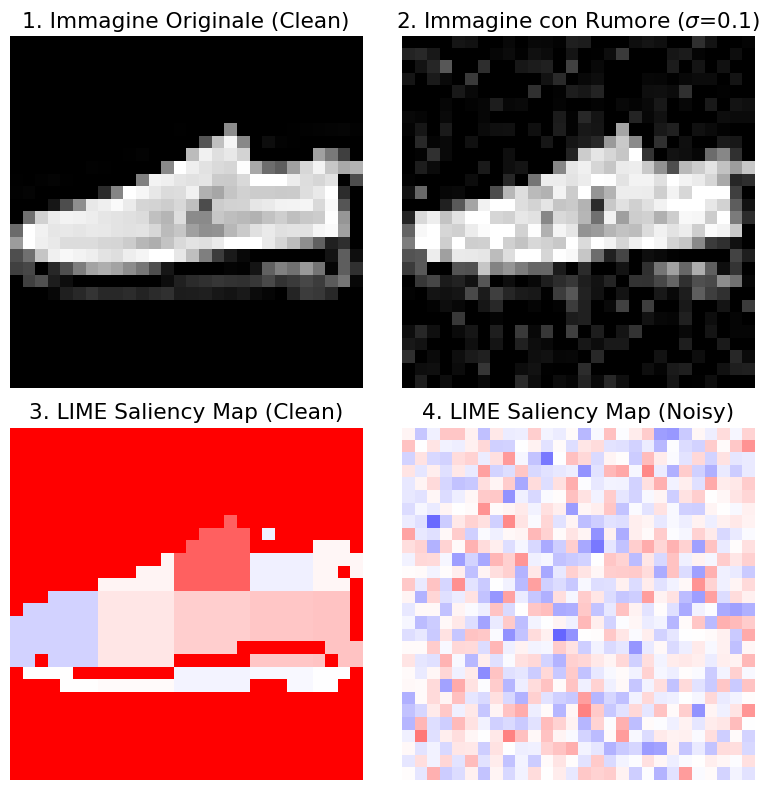

In [29]:
import matplotlib.pyplot as plt

# 1. Run on noisy image
# target=clean_pred to explain the SAME class
torch.manual_seed(0)
print("Calcolo LIME per l'immagine con rumore in corso...")
attr_noisy = lime_method.attribute(
    neighbors_norm,
    target=clean_pred, 
    n_samples=2000,
    show_progress=True
)
print("Calcolo completato!")

# 2. PREPARAZIONE DATI PER IL PLOT
# Togliamo le dimensioni extra (batch e canali) e passiamo a numpy
img_clean_plot = x_target.squeeze().cpu().numpy()
img_noisy_plot = neighbors_pix.squeeze().cpu().numpy()

# Le due mappe di LIME da confrontare
map_clean_plot = attr_clean.squeeze().cpu().numpy()
map_noisy_plot = attr_noisy.squeeze().cpu().numpy()

# 3. CREAZIONE DELLA FIGURA (Confronto Visivo)
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Prima riga: Le Immagini
axes[0, 0].imshow(img_clean_plot, cmap='gray')
axes[0, 0].set_title("1. Immagine Originale (Clean)")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_noisy_plot, cmap='gray')
axes[0, 1].set_title(f"2. Immagine con Rumore ($\sigma$={sigma})")
axes[0, 1].axis('off')

# Seconda riga: Le Saliency Maps di LIME
# Usiamo cmap='bwr' (Blue-White-Red) tipico per le saliency map
# Fissiamo vmin e vmax per avere la stessa scala di colori in entrambe
vmax = max(map_clean_plot.max(), map_noisy_plot.max())
vmin = -vmax

axes[1, 0].imshow(map_clean_plot, cmap='bwr', vmin=vmin, vmax=vmax)
axes[1, 0].set_title("3. LIME Saliency Map (Clean)")
axes[1, 0].axis('off')

axes[1, 1].imshow(map_noisy_plot, cmap='bwr', vmin=vmin, vmax=vmax)
axes[1, 1].set_title("4. LIME Saliency Map (Noisy)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## with segmentation

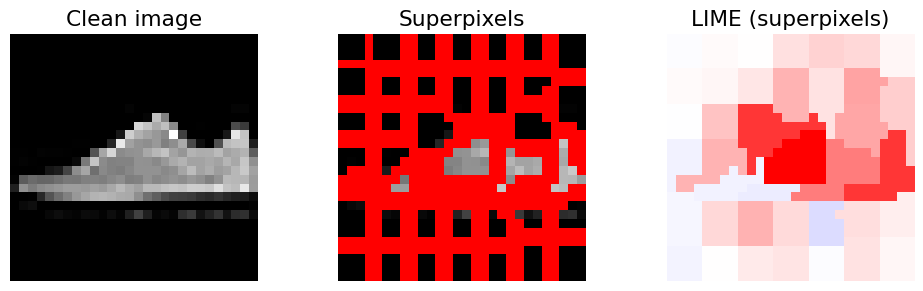

In [30]:
import numpy as np
from skimage.segmentation import slic, mark_boundaries

# Load LIME superpixel outputs
sp_dir = Path("results/fashion_mnist_lambda1e-2_c5_seed29/posthoc_superpixels")
sp_labels = torch.load(sp_dir / "lime_labels.pt")
sp_attrs  = torch.load(sp_dir / "lime_attributions.pt")
sp_preds  = torch.load(sp_dir / "lime_predictions.pt")

# Pick the same sneaker index as before
sneaker_indices = (sp_labels == 7).nonzero(as_tuple=True)[0]
i = sneaker_indices[11].item()

# Get the matching image from the test set
x_i, y_i = test_dl.dataset[i]  # x_i is normalized
x_i = x_i.unsqueeze(0)         # [1,1,28,28]

# Attribution for that image
attr_i = sp_attrs[i].squeeze().cpu().numpy()  # [28,28]

# Denormalize for visualization
img_pix = denormalize(x_i).clamp(0, 1)[0, 0].cpu().numpy()

# Superpixels (match run_lime.py defaults)
sp = slic(img_pix, n_segments=50, compactness=0.1, start_label=0, channel_axis=None)

# Plot
vmax = np.max(np.abs(attr_i))
vmin = -vmax

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(img_pix, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Clean image")
axes[0].axis("off")

axes[1].imshow(mark_boundaries(img_pix, sp, color=(1, 0, 0)))
axes[1].set_title("Superpixels")
axes[1].axis("off")

axes[2].imshow(attr_i, cmap="bwr", vmin=vmin, vmax=vmax)
axes[2].set_title("LIME (superpixels)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## LIME version 2

Saved results contain 200 images
Class distribution: {0: 20, 1: 27, 2: 27, 3: 17, 4: 21, 5: 16, 6: 16, 7: 20, 8: 18, 9: 18}
Found 21 sneakers in saved results
Visualizing saved index 51 | true label: 4 | pred: 2


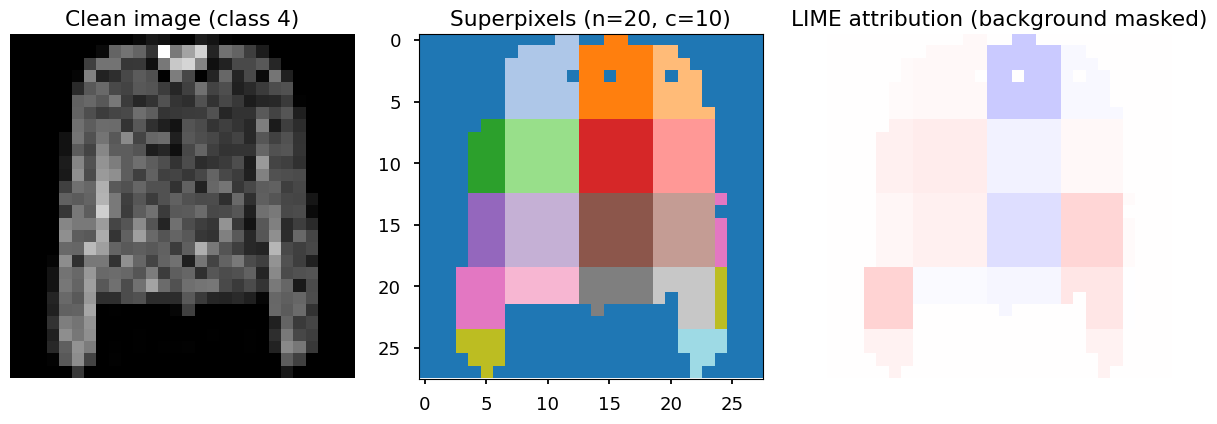

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.segmentation import slic, mark_boundaries

# FashionMNIST constants (must match run_lime.py)
FMNIST_MEAN = 0.2860
FMNIST_STD  = 0.3530

def denormalize(x):
    return x * FMNIST_STD + FMNIST_MEAN

# ── Load saved LIME results ───────────────────────────────────────────────────
sp_dir = Path("results/fashion_mnist_lambda1e-2_c5_seed29/posthoc_superpixels_3imgtest")

sp_attrs  = torch.load(sp_dir / "lime_attributions.pt")  # (N, 1, 28, 28)
sp_labels = torch.load(sp_dir / "lime_labels.pt")        # (N,)
sp_preds  = torch.load(sp_dir / "lime_predictions.pt")   # (N,)

print(f"Saved results contain {sp_attrs.shape[0]} images")
print(f"Class distribution: { {c.item(): (sp_labels==c).sum().item() for c in sp_labels.unique()} }")

# ── Pick an image ─────────────────────────────────────────────────────────────
# All indices here are into the SAVED results, not the full test set
# sp_attrs[k] and test_dl correspond to the same k-th image

TARGET_CLASS = 4  # sneaker
sneaker_indices = (sp_labels == TARGET_CLASS).nonzero(as_tuple=True)[0]
print(f"Found {len(sneaker_indices)} sneakers in saved results")

k = sneaker_indices[6].item()  # pick the first one; change index to browse others
print(f"Visualizing saved index {k} | true label: {sp_labels[k].item()} | pred: {sp_preds[k].item()}")

# ── Get the matching image from the test loader ───────────────────────────────
# k-th image in test_dl corresponds to sp_attrs[k]
x_norm, y = test_dl.dataset[k]   # normalized tensor (1, 28, 28)
assert y == sp_labels[k].item(), f"Label mismatch: dataset={y}, saved={sp_labels[k].item()}"

x_pix = denormalize(x_norm).clamp(0, 1).squeeze().numpy()  # (28, 28) for plotting

# ── Attribution ───────────────────────────────────────────────────────────────
attr = sp_attrs[k].squeeze().cpu().numpy()  # (28, 28)

# ── Recompute superpixels with SAME params as run_lime.py ────────────────────
img_for_slic = x_pix  # denormalized, same as build_superpixel_mask does internally
segments = slic(img_for_slic, n_segments=20, compactness=10.0,
                start_label=1, channel_axis=None)
bg_mask = img_for_slic < 0.05
segments[bg_mask] = 0

# ── Plot ──────────────────────────────────────────────────────────────────────
vmax = np.abs(attr).max()
vmin = -vmax

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(x_pix, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[0].set_title(f"Clean image (class {y})")
axes[0].axis("off")

axes[1].imshow(segments, cmap='tab20', interpolation='nearest')
axes[1].set_title("Superpixels (n=20, c=10)")

# Mask background attribution to zero for clean visualization
attr_masked = attr.copy()
attr_masked[segments == 0] = 0

axes[2].imshow(attr_masked, cmap="bwr", vmin=vmin, vmax=vmax, interpolation="nearest")
axes[2].set_title("LIME attribution (background masked)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Find sneakers WITHIN the saved results only
sneaker_indices = (sp_labels == 7).nonzero(as_tuple=True)[0]
idx_in_saved = sneaker_indices[0].item()  # first sneaker in saved results

# Get the attribution (valid, LIME saw this)
attr_i = sp_attrs[idx_in_saved].squeeze().cpu().numpy()

# Get the MATCHING image — need to know which test set image this corresponds to
# The saved results are in test loader order, so:
# idx_in_saved maps directly to the idx_in_saved-th image the loader returned
x_i, y_i = test_dl.dataset[idx_in_saved]  # only valid if batch_size >= idx_in_saved